### Exploring The Android's Corpus available metadata

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('metadata.csv')
print(df.head())

            RT   AGE SEX P/C           IT  AGE.1 SEX.1 P/C.1
0  '01_CF56_1'  56.0   F   C  '01_CF56_1'     56     F     C
1  '02_CM57_2'  57.0   M   C  '02_CM57_2'     57     M     C
2  '09_CF56_3'  56.0   F   C  '18_CM64_3'     64     M     C
3  '21_CF58_3'  58.0   F   C  '20_CM51_3'     51     M     C
4  '22_CF50_3'  50.0   F   C  '22_CF50_3'     50     F     C


In [37]:
df.tail()

,RT,AGE,SEX,P/C,IT,AGE.1,SEX.1,P/C.1
111,'72_PM53_1',53.0,M,P,'33_PM19_3',19,M,P
112,NaN,NaN,NaN,NaN,'47_PF42_2',42,F,P
113,NaN,NaN,NaN,NaN,'51_PF58_2',58,F,P
114,NaN,NaN,NaN,NaN,'54_PF48_3',48,F,P
115,NaN,NaN,NaN,NaN,'68_PF43_3',43,F,P


In [9]:
df.isnull().sum()

RT       4
AGE      4
SEX      4
P/C      4
IT       0
AGE.1    0
SEX.1    0
P/C.1    0
dtype: int64

In [10]:
df.shape

(116, 8)

There are 110 patients for both tasks, 114 for the Interview Task

In [13]:
df.describe()

,AGE,AGE.1
count,112.000000,116.000000
mean,47.223214,47.387931
std,12.269283,12.063435
min,19.000000,19.000000
25%,37.000000,37.750000
50%,49.500000,50.000000
75%,56.250000,56.000000
max,71.000000,71.000000


# Ages RT

In [12]:
rt_ages = df['AGE'].dropna()
rt_ages.head()

0    56.0
1    57.0
2    56.0
3    58.0
4    50.0
Name: AGE, dtype: float64

In [25]:
rt_ages.shape

(112,)

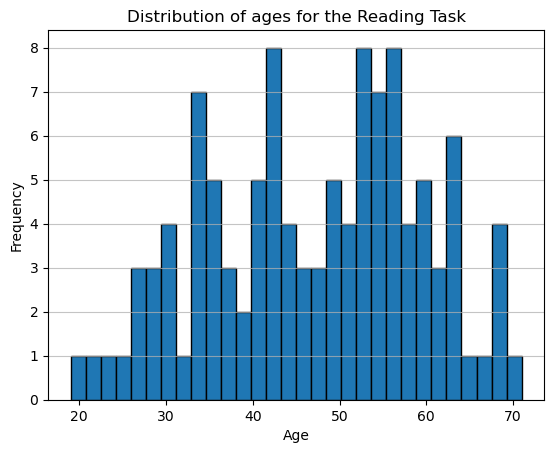

In [23]:
plt.hist(rt_ages, bins=30, edgecolor='black')
plt.title('Distribution of ages for the Reading Task')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [24]:
import numpy as np

print(f"Mean of the ages in the reading task {np.mean(rt_ages)}")
print(f"Median of the ages in the reading task {np.median(rt_ages)}")
print(f"Standard deviation of the ages in the reading task {np.std(rt_ages)}")

Mean of the ages in the reading task 47.223214285714285
Median of the ages in the reading task 49.5
Standard deviation of the ages in the reading task 12.214386878236029


# Ages IT

In [28]:
it_ages = df['AGE.1'].dropna()
print(it_ages.head())
print(it_ages.shape)

0    56
1    57
2    64
3    51
4    50
Name: AGE.1, dtype: int64
(116,)


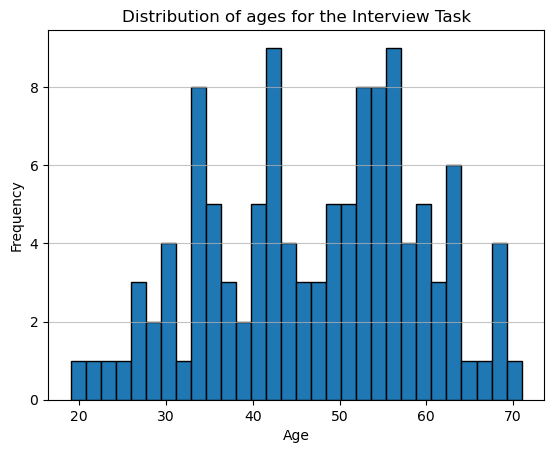

In [30]:
plt.hist(it_ages, bins=30, edgecolor='black')
plt.title('Distribution of ages for the Interview Task')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [31]:
import numpy as np

print(f"Mean of the ages in the interview task {np.mean(it_ages)}")
print(f"Median of the ages in the interview task {np.median(it_ages)}")
print(f"Standard deviation of the ages in the interview task {np.std(it_ages)}")

Mean of the ages in the interview task 47.38793103448276
Median of the ages in the interview task 50.0
Standard deviation of the ages in the interview task 12.011324793942947


# Ages total

In [35]:
ages = pd.concat([rt_ages, it_ages], ignore_index=True)
ages.head()

print(ages.shape)

(228,)


In [36]:
ages.tail()

223    19.0
224    42.0
225    58.0
226    48.0
227    43.0
dtype: float64

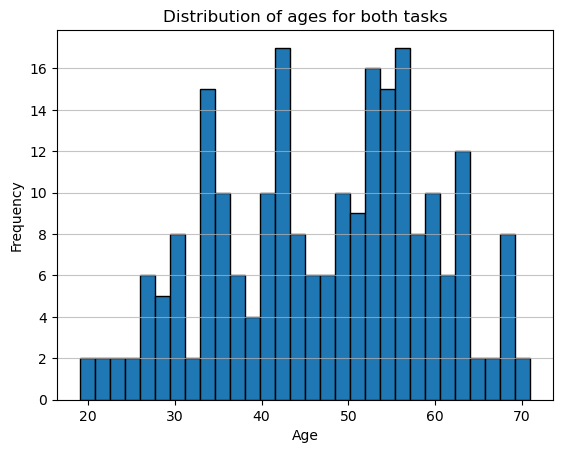

In [41]:
plt.hist(ages, bins=30, edgecolor='black')
plt.title('Distribution of ages for both tasks')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [42]:
import scipy.stats as stats

# Shapiro-Wilk test for normality
shapiro_rt = stats.shapiro(rt_ages)
shapiro_it = stats.shapiro(it_ages)
shapiro_total = stats.shapiro(ages)

ModuleNotFoundError: No module named 'scipy'

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def test_normality(data):
    print("--- Normality Tests ---")
    
    # 1. Shapiro-Wilk Test
    # Note: Shapiro-Wilk may not be accurate for N > 5000
    stat_sw, p_sw = stats.shapiro(data)
    print(f"Shapiro-Wilk Test:       Statistic = {stat_sw:.4f}, p-value = {p_sw:.4f}")
    if p_sw < 0.05:
        print("  -> Result: The distribution is NOT normal (Reject H0).")
    else:
        print("  -> Result: The distribution looks normal (Fail to reject H0).")

    print("")

    # 2. D'Agostino's K-squared Test
    # Note: Requires at least 20 data points
    if len(data) >= 20:
        stat_k2, p_k2 = stats.normaltest(data)
        print(f"D'Agostino's K-squared:  Statistic = {stat_k2:.4f}, p-value = {p_k2:.4f}")
        if p_k2 < 0.05:
            print("  -> Result: The distribution is NOT normal (Reject H0).")
        else:
            print("  -> Result: The distribution looks normal (Fail to reject H0).")
    else:
        print("D'Agostino's K-squared:  Dataset too small (N < 20) for this test.")

    print("-----------------------")

    # 3. Visual Check: Q-Q Plot
    plt.figure(figsize=(7, 5))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title("Q-Q Plot against Normal Distribution")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# ==========================================
# Example usage:
# ==========================================
if __name__ == "__main__":
    # Replace this array with your actual data
    # my_data = np.array([1.2, 2.4, 3.1, ...])
    
    # Simulating a dataset that IS normally distributed
    print("Testing a True Normal Distribution:")
    normal_data = np.random.normal(loc=0, scale=1, size=200)
    test_normality(normal_data)
    
    # Simulating a dataset that is NOT normally distributed (e.g., skewed)
    print("\nTesting a Skewed (Non-Normal) Distribution:")
    skewed_data = np.random.exponential(scale=2, size=200)
    test_normality(skewed_data)
